# Tuanas Preliminary results

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import ICIW_Plots

plt.style.use(["ICIWstyle"])
plt.rcParams.update(
    {
        "font.size": 10,
    }
)

## Laminar Flow model


In [4]:
t_in = np.load(r"data\laminar_flow\time.npy").squeeze()
x_0 = np.ones_like(t_in)
x_0[t_in < 5] = 0.0
x = np.load(r"data\laminar_flow\concentration.npy").squeeze()
x_nRTD = np.load(r"data\laminar_flow\c_conv_in.npy").squeeze()
E = np.load(r"data\laminar_flow\E_expected.npy").squeeze()
E_nRTD = np.load(r"data\laminar_flow\E_predicted.npy").squeeze()
t_E = np.load(r"data\laminar_flow\t_E_predicted.npy").squeeze()

In [5]:
E = E / np.trapz(E, t_E)
E_nRTD = E_nRTD / np.trapz(E_nRTD, t_E)

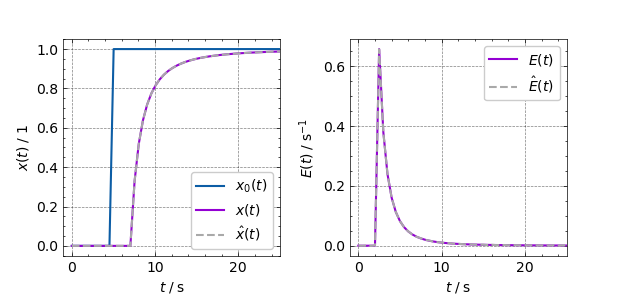

In [6]:
fig = ICIW_Plots.figure(layout="double_column")
axs = ICIW_Plots.make_square_subplots(
    fig,
    ax_width=5.5 * ICIW_Plots.cm2inch,
    ax_layout=(1, 2),
    h_sep=0.7,
    xlabel=r"$t \;/\; \mathrm{s}$",
    ylabel=[[r"$x(t)\;/\;1$", r"$E(t)\;/\;\mathrm{s}^{-1}$"]],
    xlim=(-1, 25),
)
axs[0, 0].plot(t_in, x_0, label="$x_0(t)$")
axs[0, 0].plot(t_in, x, color="darkviolet", label="$x(t)$")
axs[0, 0].plot(t_in, x_nRTD, color="darkgrey", ls="--", label=r"$\hat{x}(t)$")
axs[0, 1].plot(t_E, E, color="darkviolet", label="$E(t)$")
axs[0, 1].plot(t_E, E_nRTD, color="darkgrey", ls="--", label=r"$\hat{E}(t)$")
axs[0, 0].legend()
axs[0, 1].legend()

plt.savefig("lam_flow.png", dpi=600)
plt.savefig("lam_flow.svg")

## Dispersion Model

In [7]:
t_in = np.load(r"data\dispersion\time.npy").squeeze()
x_0 = np.ones_like(t_in)
x_0[t_in < 5] = 0.0
x = np.load(r"data\dispersion\concentration.npy").squeeze()
E = np.load(r"data\dispersion\E_expected.npy").squeeze()
E_nRTD = np.load(r"data\dispersion\E_predicted.npy").squeeze()
t_E = np.load(r"data\dispersion\t_E_predicted.npy").squeeze()

x_nRTD = np.convolve(x_0, E_nRTD, mode="full")
x_nRTD = x_nRTD[: len(x)]  # truncate to the length of x
x_nRTD /= max(x_nRTD)  # normalize to the maximum of x

In [8]:
E = E / np.trapz(E, t_E)
E_nRTD = E_nRTD / np.trapz(E_nRTD, t_E)

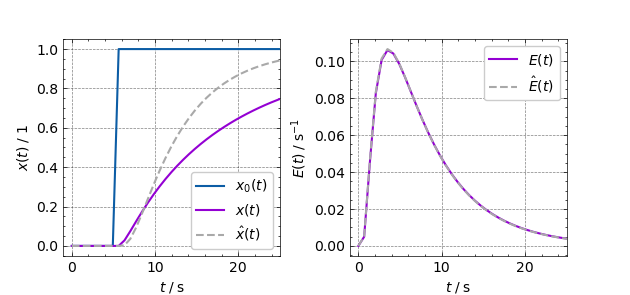

In [9]:
fig = ICIW_Plots.figure(layout="double_column")
axs = ICIW_Plots.make_square_subplots(
    fig,
    ax_width=5.5 * ICIW_Plots.cm2inch,
    ax_layout=(1, 2),
    h_sep=0.7,
    xlabel=r"$t \;/\; \mathrm{s}$",
    ylabel=[[r"$x(t)\;/\;1$", r"$E(t)\;/\;\mathrm{s}^{-1}$"]],
    xlim=(-1, 25),
)
axs[0, 0].plot(t_in, x_0, label="$x_0(t)$")
axs[0, 0].plot(t_in, x, color="darkviolet", label="$x(t)$")
axs[0, 0].plot(t_in, x_nRTD, color="darkgrey", ls="--", label=r"$\hat{x}(t)$")
axs[0, 1].plot(t_E, E, color="darkviolet", label="$E(t)$")
axs[0, 1].plot(t_E, E_nRTD, color="darkgrey", ls="--", label=r"$\hat{E}(t)$")
axs[0, 0].legend()
axs[0, 1].legend()

plt.savefig("dispersion.png", dpi=600)
plt.savefig("dispersion.svg")

## Cholette-Clautier oder so

In [10]:
t_in = np.load(r"data\cholette\time.npy").squeeze()
x_0 = np.ones_like(t_in)
x_0[t_in < 5] = 0.0
x = np.load(r"data\cholette\concentration.npy").squeeze()
E = np.load(r"data\cholette\E_expected.npy").squeeze()
E = E / np.max(E)  # normalize to the maximum of E
E_nRTD = np.load(r"data\cholette\E_predicted.npy").squeeze()
t_E = np.load(r"data\cholette\t_E_predicted.npy").squeeze()

x_nRTD = np.convolve(x_0, E_nRTD, mode="full")
x_nRTD = x_nRTD[: len(x)]  # truncate to the length of x
x_nRTD /= np.max(x_nRTD)  # normalize to the maximum of x

In [11]:
E = E / np.trapz(E, t_E)
E_nRTD = E_nRTD / np.trapz(E_nRTD, t_E)

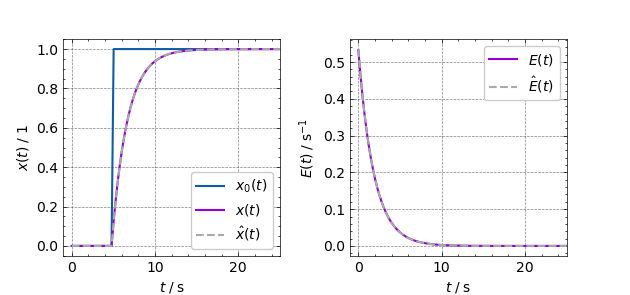

In [12]:
fig = ICIW_Plots.figure(layout="double_column")
axs = ICIW_Plots.make_square_subplots(
    fig,
    ax_width=5.5 * ICIW_Plots.cm2inch,
    ax_layout=(1, 2),
    h_sep=0.7,
    xlabel=r"$t \;/\; \mathrm{s}$",
    ylabel=[[r"$x(t)\;/\;1$", r"$E(t)\;/\;\mathrm{s}^{-1}$"]],
    xlim=(-1, 25),
)
axs[0, 0].plot(t_in, x_0, label="$x_0(t)$")
axs[0, 0].plot(t_in, x, color="darkviolet", label="$x(t)$")
axs[0, 0].plot(t_in, x_nRTD, color="darkgrey", ls="--", label=r"$\hat{x}(t)$")
axs[0, 1].plot(t_E, E, color="darkviolet", label="$E(t)$")
axs[0, 1].plot(t_E, E_nRTD, color="darkgrey", ls="--", label=r"$\hat{E}(t)$")
axs[0, 0].legend()
axs[0, 1].legend()

plt.savefig("cholete.png", dpi=600)
plt.savefig("cholete.svg")

## Adler-Hovorka oder so

In [13]:
t_in = np.load(r"data\adler\time.npy").squeeze()
x_0 = np.ones_like(t_in)
x_0[t_in < 5] = 0.0
x = np.load(r"data\adler\concentration.npy").squeeze()
E = np.load(r"data\adler\E_expected.npy").squeeze()
E = E / np.max(E)  # normalize to the maximum of E
E_nRTD = np.load(r"data\adler\E_predicted.npy").squeeze()
t_E = np.load(r"data\adler\t_E_predicted.npy").squeeze()

x_nRTD = np.convolve(x_0, E_nRTD, mode="full")
x_nRTD = x_nRTD[: len(x)]  # truncate to the length of x
x_nRTD /= np.max(x_nRTD)  # normalize to the maximum of x

In [14]:
E = E / np.trapz(E, t_E)
E_nRTD = E_nRTD / np.trapz(E_nRTD, t_E)

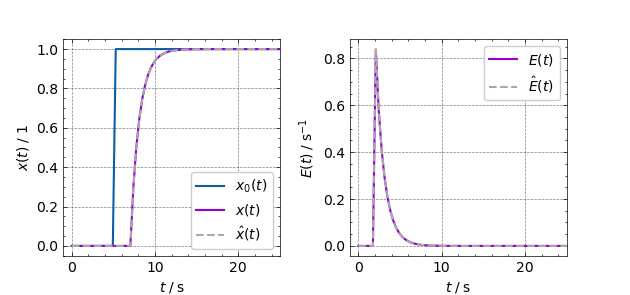

In [15]:
fig = ICIW_Plots.figure(layout="double_column")
axs = ICIW_Plots.make_square_subplots(
    fig,
    ax_width=5.5 * ICIW_Plots.cm2inch,
    ax_layout=(1, 2),
    h_sep=0.7,
    xlabel=r"$t \;/\; \mathrm{s}$",
    ylabel=[[r"$x(t)\;/\;1$", r"$E(t)\;/\;\mathrm{s}^{-1}$"]],
    xlim=(-1, 25),
)
axs[0, 0].plot(t_in, x_0, label="$x_0(t)$")
axs[0, 0].plot(t_in, x, color="darkviolet", label="$x(t)$")
axs[0, 0].plot(t_in, x_nRTD, color="darkgrey", ls="--", label=r"$\hat{x}(t)$")
axs[0, 1].plot(t_E, E, color="darkviolet", label="$E(t)$")
axs[0, 1].plot(t_E, E_nRTD, color="darkgrey", ls="--", label=r"$\hat{E}(t)$")
axs[0, 0].legend()
axs[0, 1].legend()

plt.savefig("adler_hovorka.png", dpi=600)
plt.savefig("adler_hovorka.svg")